# Importing

In [4]:
#!pip install pmdarima

In [1]:
import pandas as pd 
from statsmodels.graphics.tsaplots import month_plot,quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima,ARIMA,model_selection
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error,mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Cleaning--- First View

In [3]:
df=pd.read_csv("train.csv")

In [5]:
df=df[['Order Date','Sales']]

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [13]:
df

,Order Date,Sales
0,2017-11-08,261.9600
1,2017-11-08,731.9400
2,2017-06-12,14.6200
3,2016-10-11,957.5775
4,2016-10-11,22.3680
...,...,...
9795,2017-05-21,3.7980
9796,2016-01-12,10.3680
9797,2016-01-12,235.1880
9798,2016-01-12,26.3760


In [15]:
df.set_index('Order Date', inplace=True)

In [17]:
# mirar si  las fechas estan ordenadas cronologicamente 
print(df.index.is_monotonic_increasing)

False


In [19]:
# orgqnizando el df cronologicamente 
df.sort_index(inplace=True) 

In [21]:
print(df.index)

DatetimeIndex(['2015-01-03', '2015-01-04', '2015-01-04', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-06', '2015-01-06',
               '2015-01-06', '2015-01-06',
               ...
               '2018-12-29', '2018-12-29', '2018-12-29', '2018-12-30',
               '2018-12-30', '2018-12-30', '2018-12-30', '2018-12-30',
               '2018-12-30', '2018-12-30'],
              dtype='datetime64[ns]', name='Order Date', length=9800, freq=None)


In [23]:
print('fecha de inicio',df.index.min())
print('fecha final',df.index.max())

fecha de inicio 2015-01-03 00:00:00
fecha final 2018-12-30 00:00:00


In [25]:
# mirando si el df cumple un rango en tiempo (dias(D),semanas...)
rango_completo = pd.date_range(start=df.index.min(), end=df.index.max(), freq='W-SUN')
huecos = rango_completo.difference(df.index)

print(f"Fechas faltantes: {len(huecos)}")  # Número de "DATES" ausentes
print(huecos)  # Muestra las fechas específicas que faltan

Fechas faltantes: 7
DatetimeIndex(['2015-01-25', '2015-03-08', '2016-04-03', '2016-08-14',
               '2017-01-01', '2017-01-29', '2017-02-26'],
              dtype='datetime64[ns]', freq=None)


In [16]:
df

,Sales
Order Date,
2015-01-03,16.448
2015-01-04,3.540
2015-01-04,272.736
2015-01-04,11.784
2015-01-05,19.536
...,...
2018-12-30,20.720
2018-12-30,323.136
2018-12-30,209.300


In [27]:
df=df.resample('W-SUN').mean()

In [29]:
df

,Sales
Order Date,
2015-01-04,76.127000
2015-01-11,271.712235
2015-01-18,229.474056
2015-01-25,140.570182
2015-02-01,148.700824
...,...
2018-12-02,285.705556
2018-12-09,165.671085
2018-12-16,140.766268


In [18]:
# forward fill para rellenar valores faltantes 
df = df.resample('W-SUN').last().ffill()

# EDA

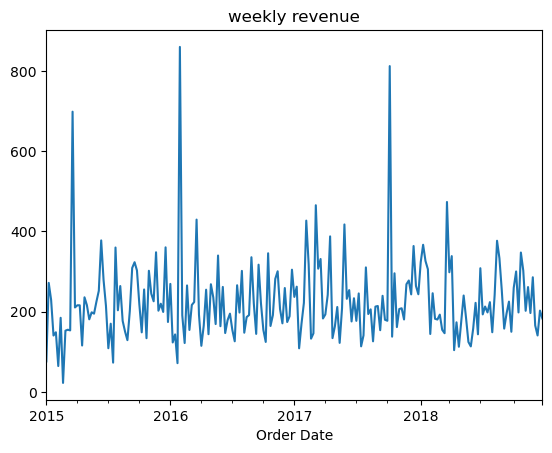

In [20]:
df['Sales'].plot(title='weekly revenue')
plt.show()

C:\Users\Nicol\AppData\Local\Temp\ipykernel_14392\685882775.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_plot(df['Sales'].resample('M').mean(),


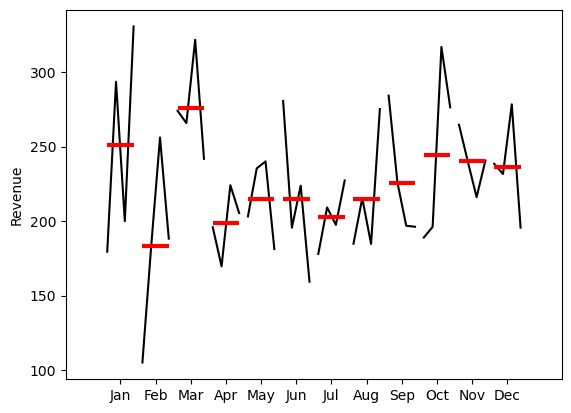

In [21]:
month_plot(df['Sales'].resample('M').mean(),
          ylabel='Revenue')
plt.show()

C:\Users\Nicol\AppData\Local\Temp\ipykernel_14392\942931476.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df['Sales'].resample('Q').mean(),


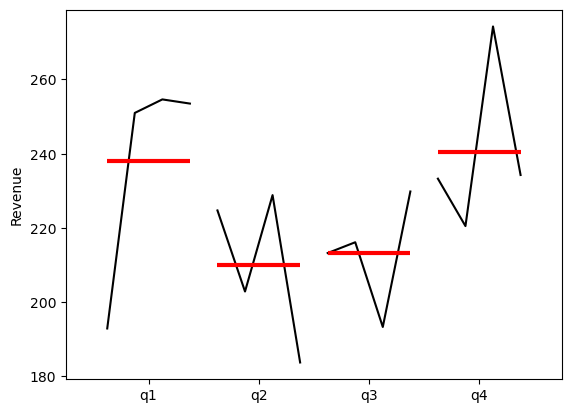

In [22]:
quarter_plot(df['Sales'].resample('Q').mean(),
          ylabel='Revenue')
plt.show()

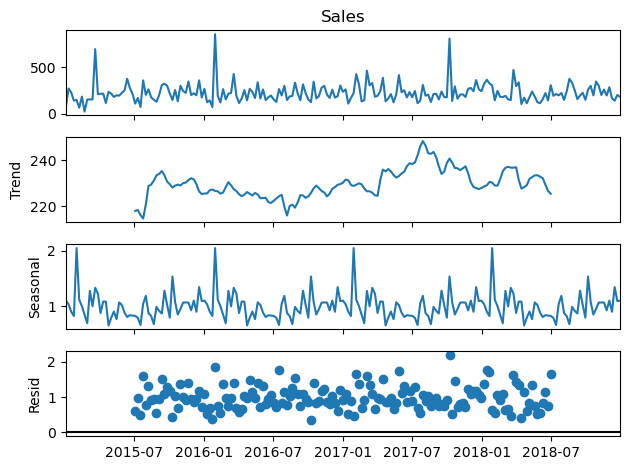

In [23]:
decomposition_mul=seasonal_decompose(df['Sales'],model='multiplicative',period=52)
fig=decomposition_mul.plot()

In [24]:
print(f'promedio residuales descompocision multiplicativa: {decomposition_mul.resid.mean()}')

promedio residuales descompocision multiplicativa: 0.9922087105217309


In [25]:
print(f"Desviación estándar residuos multiplicativo: {decomposition_mul.resid.std()}")

Desviación estándar residuos multiplicativo: 0.3402019073765883


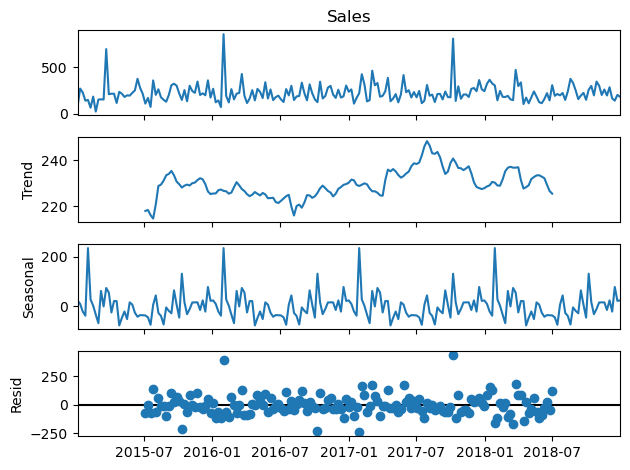

In [26]:
decomposition_add=seasonal_decompose(df['Sales'],model='additive',period=52)
fig=decomposition_add.plot()

In [27]:
print(f'promedio residuales descompocision aditiva: {decomposition_add.resid.mean()}')

promedio residuales descompocision aditiva: -1.8459262693783878


In [28]:
print(f"Desviación estándar residuos aditivo: {decomposition_add.resid.std()}")

Desviación estándar residuos aditivo: 91.3595570313759


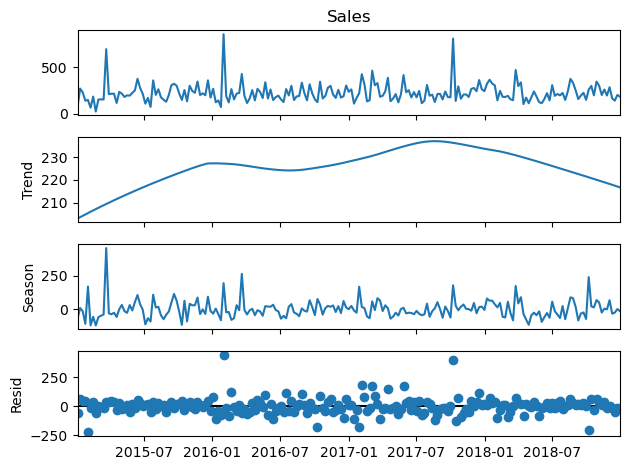

In [29]:
df_stl=STL(df['Sales'],period=52).fit()
fig=df_stl.plot()

In [30]:
print(f'promedio de resiudlaes STl:{df_stl.resid.mean()}')

promedio de resiudlaes STl:0.8381559730051917


In [31]:
print(f"Desviación estándar residuos stl: {df_stl.resid.std()}")

Desviación estándar residuos stl: 71.36549160723496


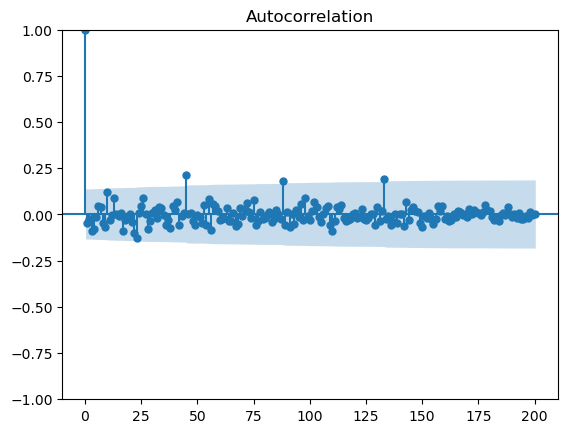

In [32]:
plot_acf(df['Sales'],lags=200)
plt.show()

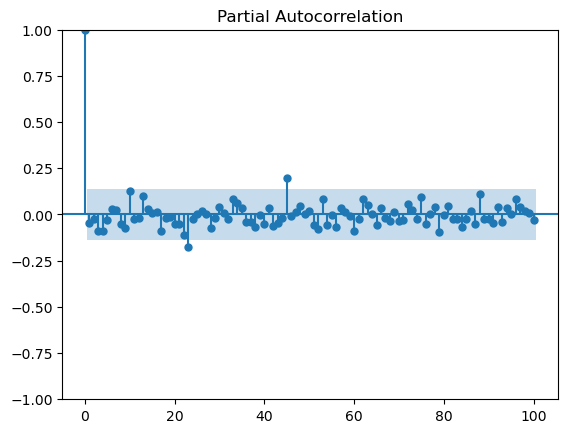

In [33]:
plot_pacf(df['Sales'],lags=100)
plt.show()

# ARIMA

## Stationary

In [36]:
# perform adf (Augmented Dickey-Fuller test) test to find if its stationary the time series 

result=adfuller(df.Sales)
print("p-value %f"%result[1]) # p-value result[1]

if result[1]<0.05:
    print("evidence suggests that the time series is stationary")
else:
    print("evidence suggests that the time series is not stationary ")


p-value 0.000000
evidence suggests that the time series is stationary


## Making the series stationary 

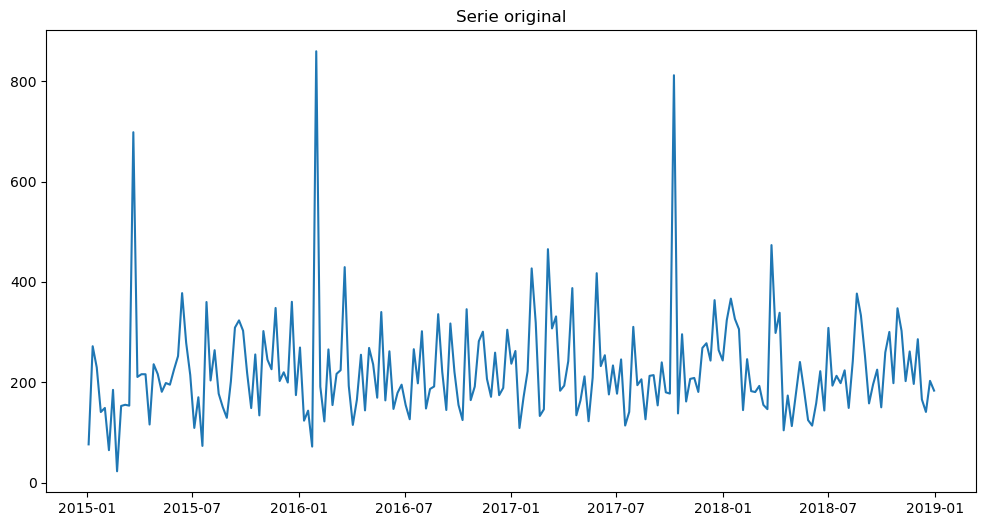

In [38]:
y = df['Sales']
plt.figure(figsize=(12,6))
plt.plot(y)
plt.title('Serie original')
plt.show()

In [39]:
# applying differencing and deleting nan values
y_diff = y.diff().dropna()

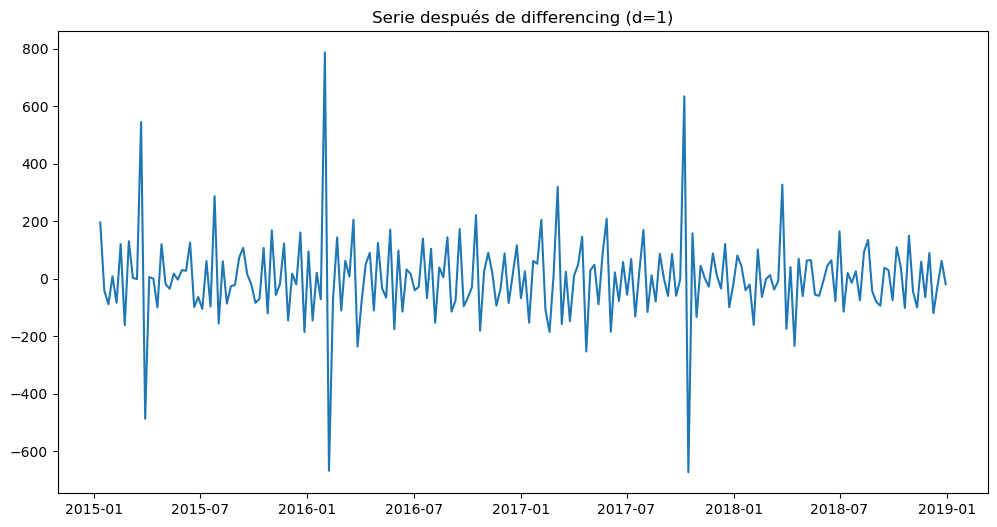

In [40]:
plt.figure(figsize=(12,6))
plt.plot(y_diff)
plt.title('Serie después de differencing (d=1)')
plt.show()

## ARIMA MODEL

In [42]:
df

,Sales
Order Date,
2015-01-04,76.127000
2015-01-11,271.712235
2015-01-18,229.474056
2015-01-25,140.570182
2015-02-01,148.700824
...,...
2018-12-02,285.705556
2018-12-09,165.671085
2018-12-16,140.766268


In [43]:
# splitting into training and test
test_weeks=20
train,test=df.iloc[:-test_weeks],df.iloc[-test_weeks:]

In [44]:
# modelling
model=auto_arima(train['Sales'],
                seasonal=False)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  189
Model:                        SARIMAX   Log Likelihood               -1150.661
Date:                Mon, 16 Jun 2025   AIC                           2305.321
Time:                        18:05:52   BIC                           2311.805
Sample:                    01-04-2015   HQIC                          2307.948
                         - 08-12-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    224.3725     11.011     20.377      0.000     202.791     245.954
sigma2      1.137e+04    636.874     17.847      0.000    1.01e+04    1.26e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.65   Jarque-Bera (JB):              1273.66
Prob(Q):                              0.42   Prob(JB):                         0.00
Heteroskedasticity (H):               0.67   Skew:                             2.62
Prob(H) (two-sided):                  0.11   Kurtosis:                        14.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [45]:
prediction_arima=model.predict(n_periods=len(test))
prediction_arima

2018-08-19    224.372543
2018-08-26    224.372543
2018-09-02    224.372543
2018-09-09    224.372543
2018-09-16    224.372543
2018-09-23    224.372543
2018-09-30    224.372543
2018-10-07    224.372543
2018-10-14    224.372543
2018-10-21    224.372543
2018-10-28    224.372543
2018-11-04    224.372543
2018-11-11    224.372543
2018-11-18    224.372543
2018-11-25    224.372543
2018-12-02    224.372543
2018-12-09    224.372543
2018-12-16    224.372543
2018-12-23    224.372543
2018-12-30    224.372543
Freq: W-SUN, dtype: float64

## Model assessment

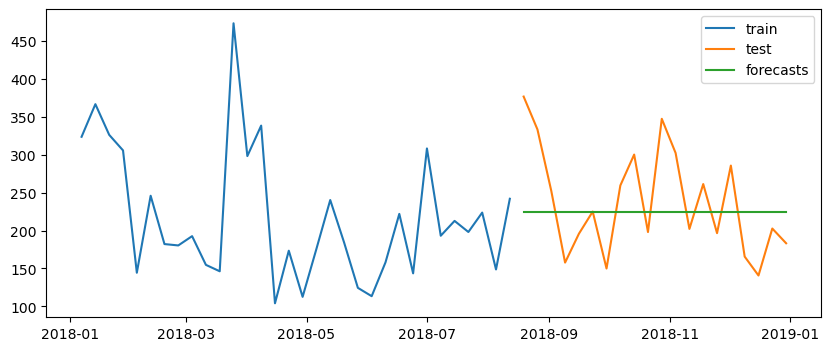

In [47]:
plt.figure(figsize=(10,4))
plt.plot(train['2018':],label='train')
plt.plot(test,label='test')
plt.plot(prediction_arima,label='forecasts')
plt.legend()
plt.show()

In [48]:
mae=mean_absolute_error(test,prediction_arima)
print(f'the mae is {mae}')

mape=mean_absolute_percentage_error(test,prediction_arima)
print(f'the mape is {100*mape:.2f}%')

the mae is 57.5427928995269
the mape is 24.64%


# SARIMA

#### the difference betwween arima and sarima is the seasonality 

In [51]:
# modelling
model_sarima=auto_arima(train['Sales'],
                m=52,
                seasonal=True)   # sarima==seasonal=True
model_sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  189
Model:                        SARIMAX   Log Likelihood               -1150.661
Date:                Mon, 16 Jun 2025   AIC                           2305.321
Time:                        18:06:26   BIC                           2311.805
Sample:                    01-04-2015   HQIC                          2307.948
                         - 08-12-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    224.3725     11.011     20.377      0.000     202.791     245.954
sigma2      1.137e+04    636.874     17.847      0.000    1.01e+04    1.26e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.65   Jarque-Bera (JB):              1273.66
Prob(Q):                              0.42   Prob(JB):                         0.00
Heteroskedasticity (H):               0.67   Skew:                             2.62
Prob(H) (two-sided):                  0.11   Kurtosis:                        14.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [52]:
prediction_sarima=model_sarima.predict(n_periods=len(test))
prediction_sarima

2018-08-19    224.372543
2018-08-26    224.372543
2018-09-02    224.372543
2018-09-09    224.372543
2018-09-16    224.372543
2018-09-23    224.372543
2018-09-30    224.372543
2018-10-07    224.372543
2018-10-14    224.372543
2018-10-21    224.372543
2018-10-28    224.372543
2018-11-04    224.372543
2018-11-11    224.372543
2018-11-18    224.372543
2018-11-25    224.372543
2018-12-02    224.372543
2018-12-09    224.372543
2018-12-16    224.372543
2018-12-23    224.372543
2018-12-30    224.372543
Freq: W-SUN, dtype: float64

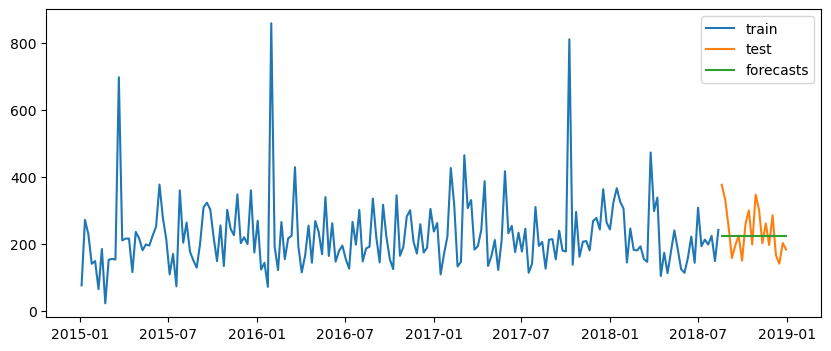

In [53]:
plt.figure(figsize=(10,4))
plt.plot(train,label='train')
plt.plot(test,label='test')
plt.plot(prediction_sarima,label='forecasts')
plt.legend()
plt.show()

### dio los mismos resultados que arima por que "Si no hay estacionalidad → SARIMA básicamente queda igual que ARIMA." y esto lo detecto el modelo automaticamente 

### Análisis del comportamiento del modelo

- Hay muchos **picos abruptos**, algunos incluso superan 800, pero la mayoría de los datos está en un rango más bajo.

- Eso hace que **no haya un patrón estacional claro**. No se observa, por ejemplo, que cada año haya un pico en las mismas fechas.

#### Predicción del modelo

- El forecast es prácticamente una **línea recta (horizontal)**.

- El modelo predice un **valor promedio (alrededor de 224)**, que coincide con el intercepto que vimos antes.

- No está capturando ni **picos**, ni **fluctuaciones**, ni **estacionalidad**.


# SARIMAX

### sarimax uses external variables to improve forecasting

In [58]:
# 1. Leer datos
df_sarimax = pd.read_csv("train.csv")

# 2. Eliminar columnas que no se  necesitan
df_sarimax.drop(['Row ID','Order ID','Customer ID','Customer Name','Product ID'], axis=1, inplace=True)

# 3. Convertir fechas 
df_sarimax['Order Date'] = pd.to_datetime(df_sarimax['Order Date'], dayfirst=True)

# 4. Definir las variables exógenas ANTES de eliminar columnas
exog_vars = pd.get_dummies(df_sarimax[['Segment', 'Category']], drop_first=True)

# 5. Mantener solo lo necesario para la serie de tiempo principal
df_sarimax = df_sarimax[['Order Date', 'Sales']]

# 6. Poner 'Order Date' como índice
df_sarimax.set_index('Order Date', inplace=True)

# 6.5 organizadno indices 
df_sarimax.sort_index(inplace=True) 

# 🔄 Nuevo: también poner índice en exógenas antes del resampleo
exog_vars.index = df_sarimax.index

# 7. Resamplear ventas semanalmente
df_sarimax = df_sarimax.resample('W-SUN').sum()

# 9. resampleando
exog_vars = exog_vars.resample('W-SUN').mean()

# 🔥 NUEVO: eliminar cualquier semana con NaN en ventas o exógenas
data = pd.concat([df_sarimax, exog_vars], axis=1).dropna()

# 11. Separar de nuevo la serie y las exógenas
y = data['Sales']
X = data.drop(columns='Sales')


# 12. Hacer train/test split temporal
n_test = 12  # por ejemplo, últimas 12 semanas
y_train, y_test = y[:-n_test], y[-n_test:]
X_train, X_test = X[:-n_test], X[-n_test:]


In [59]:
# auto_arima para mirar los mejores parametros
stepwise_model = auto_arima(y_train,
                            exogenous=X_train,
                            m=52,  # frecuencia semanal con estacionalidad anual
                            seasonal=True,
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True)
    

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[52] intercept   : AIC=4007.995, Time=9.06 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=4073.718, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=4029.736, Time=1.29 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=4003.756, Time=1.87 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=4071.759, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=4005.845, Time=0.08 sec
 ARIMA(0,1,1)(1,0,1)[52] intercept   : AIC=4005.469, Time=2.87 sec
 ARIMA(0,1,1)(0,0,2)[52] intercept   : AIC=4003.583, Time=11.82 sec
 ARIMA(0,1,1)(1,0,2)[52] intercept   : AIC=4003.662, Time=46.42 sec
 ARIMA(0,1,0)(0,0,2)[52] intercept   : AIC=4077.236, Time=4.58 sec
 ARIMA(1,1,1)(0,0,2)[52] intercept   : AIC=4004.247, Time=15.45 sec
 ARIMA(0,1,2)(0,0,2)[52] intercept   : AIC=4005.123, Time=14.76 sec
 ARIMA(1,1,0)(0,0,2)[52] intercept   : AIC=4031.713, Time=6.04 sec
 ARIMA(1,1,2)(0,0,2)[52] intercept   : AIC=inf, Time=78.61 sec
 ARIMA(0,1,1)(0,0,2

In [60]:
# 13. Extraer parámetros
order = stepwise_model.order
seasonal_order = stepwise_model.seasonal_order

In [61]:
model = SARIMAX(y_train,
                exog=X_train,
                order=order,
                seasonal_order=seasonal_order)

model_fit = model.fit(disp=False)

C:\Users\Nicol\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


In [62]:
# 15 summary of the model
print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                  197
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 52)   Log Likelihood               -1994.762
Date:                            Mon, 16 Jun 2025   AIC                           4007.524
Time:                                    18:15:01   BIC                           4037.027
Sample:                                01-04-2015   HQIC                          4019.468
                                     - 10-07-2018                                         
Covariance Type:                              opg                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Segment_Corporate         1890.9740   4693.982      0.403      0.687   -7309.062    1.

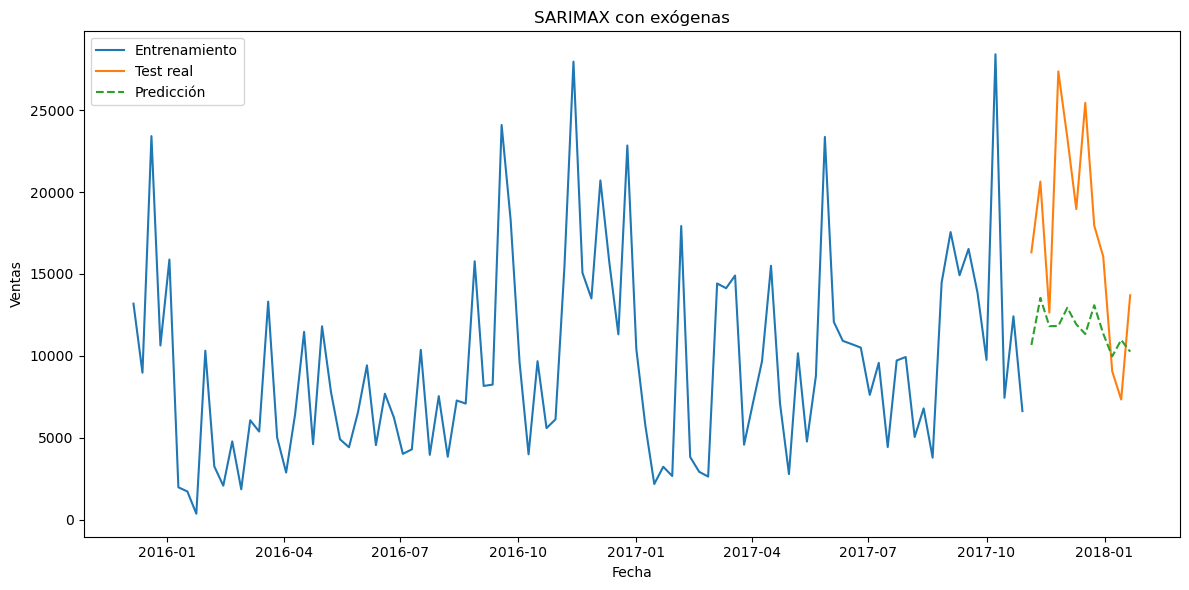

the mae is 6519.347334424932
the mape is 34.23%
the rmse is 792214.02%


In [142]:
# 15. Predecir sobre el conjunto de prueba
y_pred = model_fit.predict(start=y_test.index[0],
                           end=y_test.index[-1],
                           exog=X_test)

# 17. Graficar resultados
plt.figure(figsize=(12,6))
plt.plot(y_train, label='Entrenamiento')
plt.plot(y_test, label='Test real')
plt.plot(y_pred, label='Predicción', linestyle='--')
plt.title('SARIMAX con exógenas')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.tight_layout()
plt.show()

mae=mean_absolute_error(y_test,y_pred)
print(f'the mae is {mae}')

mape=mean_absolute_percentage_error(y_test,y_pred)
print(f'the mape is {100*mape:.2f}%')

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'the rmse is {rmse:.2f}%')


# Cross validation

### Rolling window

In [128]:
tscv = TimeSeriesSplit(n_splits=5)

print("🔄 Rolling Window Results:\n")

for i, (train_idx, test_idx) in enumerate(tscv.split(y)):
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]

    model = SARIMAX(y_train,
                    exog=X_train,
                    order=order,
                    seasonal_order=seasonal_order)

    model_fit = model.fit(disp=False)

    y_pred = model_fit.predict(start=y_test.index[0],
                               end=y_test.index[-1],
                               exog=X_test)

    mape = mean_absolute_percentage_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"Rolling Split {i+1} - MAPE: {mape:.2%} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")

🔄 Rolling Window Results:



C:\Users\Nicol\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Rolling Split 1 - MAPE: 198.15% | MAE: 5474.55 | RMSE: 6791.49


C:\Users\Nicol\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Rolling Split 2 - MAPE: 62.87% | MAE: 6021.44 | RMSE: 8066.95


...

Rolling Split 3 - MAPE: 76.12% | MAE: 4016.15 | RMSE: 5046.24


C:\Users\Nicol\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Rolling Split 4 - MAPE: 43.58% | MAE: 5321.49 | RMSE: 7264.64


C:\Users\Nicol\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


Rolling Split 5 - MAPE: 39.81% | MAE: 5890.13 | RMSE: 7744.25


In [140]:
tscv = TimeSeriesSplit(n_splits=5)

for i, (train_idx, test_idx) in enumerate(tscv.split(df_sarimax)):
    train_start = df_sarimax.index[train_idx[0]]
    train_end = df_sarimax.index[train_idx[-1]]
    test_start = df_sarimax.index[test_idx[0]]
    test_end = df_sarimax.index[test_idx[-1]]
    
    print(f"🔁 Split {i+1}")
    print(f"   - Train: {train_start.date()} → {train_end.date()} ({len(train_idx)} semanas)")
    print(f"   - Test:  {test_start.date()} → {test_end.date()} ({len(test_idx)} semanas)\n")

🔁 Split 1
   - Train: 2015-01-04 → 2015-09-27 (39 semanas)
   - Test:  2015-10-04 → 2016-05-22 (34 semanas)

🔁 Split 2
   - Train: 2015-01-04 → 2016-05-22 (73 semanas)
   - Test:  2016-05-29 → 2017-01-15 (34 semanas)

🔁 Split 3
   - Train: 2015-01-04 → 2017-01-15 (107 semanas)
   - Test:  2017-01-22 → 2017-09-10 (34 semanas)

🔁 Split 4
   - Train: 2015-01-04 → 2017-09-10 (141 semanas)
   - Test:  2017-09-17 → 2018-05-06 (34 semanas)

🔁 Split 5
   - Train: 2015-01-04 → 2018-05-06 (175 semanas)
   - Test:  2018-05-13 → 2018-12-30 (34 semanas)

